In [1]:
import torch


In [23]:
# Transformation is essentially a linear operation in this first part
torch_attention = torch.nn.MultiheadAttention(16, 1, 0, batch_first=True)
# embed_dim denotes the dimensionality of each input.
# a value of 16 means each token has 16 parallel meaning to it(whatever that could mean)
# number of heads indicates how many parallel learnings are happening
# from the tensor docs:
# num_heads – Number of parallel attention heads. Note that embed_dim will be split across num_heads (i.e. each head will have dimension embed_dim // num_heads).

k, v, q = torch.rand(20, 10, 16), torch.rand(20, 10, 16), torch.rand(20, 5, 16)
# the input here should be read as (batch, sequence length, embedding dimension of each token within the sequence)
# each sequence can be thought of as a collection of tokens(like an english sentence)
# so the above input(k,v) can be thought of as 10 sentences with each sentence of 10 words/token each. And each word is embedded in a vector of size 16
# query has a slightly different length here where the sentences in query batch have 5 words
o, _ = torch_attention(q, k, v)


In [ ]:
print(o.shape) # (batch size, sequence length, value)
# output is indicating for each sequence, and for each token in the sequence, what value/meaning we learned across each dimension
print([(n, v.shape) for n, v in list(torch_attention.named_parameters())])
# the ('in_proj_weight', torch.Size([48, 16]) is because there is linear weight for each key, value and query
# so resulting Weight matrix is [Wq, Wk, Wv]. Each of those weight is of size (16, 16)
# the shape of in_proj_weight doesn't depend on batch size, sequence length, number of heads.
# it is always (embedding_dimension X embedding_dimension)

# for a given token
# embedding [1 x 16] matrix multiplication W [16 x 16] = V/K/Q [1 x 16]

torch.Size([20, 5, 16])
[('in_proj_weight', torch.Size([48, 16])), ('in_proj_bias', torch.Size([48])), ('out_proj.weight', torch.Size([16, 16])), ('out_proj.bias', torch.Size([16]))]


In [ ]:
# MultiheadAttention implementation from scratch
# although I did not understand it 
from einops import rearrange

class MHA(torch.nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.in_proj_k = torch.nn.Linear(embed_dim, embed_dim)
        self.in_proj_v = torch.nn.Linear(embed_dim, embed_dim)
        self.in_proj_q = torch.nn.Linear(embed_dim, embed_dim)
        self.out_proj = torch.nn.Linear(embed_dim, embed_dim)
        self.n_heads = num_heads

    def forward(self, q, k, v):
        

        p_q, p_k, p_v = self.in_proj_q(q), self.in_proj_k(k), self.in_proj_v(v)

        r_q = rearrange(p_q, "b m (h d) -> b h m d", h=self.n_heads)
        r_k = rearrange(p_k, "b n (h d) -> b h n d", h=self.n_heads)
        r_v = rearrange(p_v, "b n (h d) -> b h n d", h=self.n_heads)

        scores = torch.einsum("b h m d, b h n d -> b h m n", r_q, r_k)
        attn = torch.nn.functional.softmax(scores, dim=-1)
        result = torch.einsum("b h m n, b h n d -> b h m d", attn, r_v)
        r_result = rearrange(result, "b h m d -> b m (h d)")
        return self.out_proj(r_result)


our_attention = MHA(16, 4)
o_our = our_attention(q, k, v)
o_torch, _ = torch_attention(q, k, v)

print(o_our.shape, o_torch.shape)

torch.Size([20, 5, 16]) torch.Size([20, 5, 16])


In [ ]:
#Implicit function example of Positional Embedding

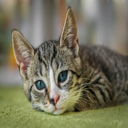

In [28]:
import numpy as np
import torch
from PIL import Image

im = Image.open("cat.jpg")
im_small = im.resize((128, 128))
im_small

In [ ]:
class PositionalEmbedding(torch.nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        # cosine frequency based position embedding used(I did not understand much)
        self.freq = torch.exp(torch.arange(0, embed_dim, 2).float() / 2)

    def forward(self, x):
        # x.shape  B x 2 (It is 2 since the input has 2 position coordinates X and Y)
        x = x[..., None, :] * self.freq[..., None].to(x.device)
        return torch.cat([torch.sin(x), torch.cos(x)], dim=-1).view(*x.shape[:-2], -1)


# f, ax = plt.subplots(3, 3, figsize=(5, 5))

# pe = PositionalEmbedding(8)
# e = pe(torch.linspace(-1, 1, 100)[:, None])
# for i in range(8):
#     ax[i // 3, i % 3].plot(e[:, i].numpy())

/home/akash/Documents/projects/MSAI/env/lib/python3.12/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


0.13462595641613007
0.044744931161403656
0.03141004219651222
0.025557424873113632
0.02075633406639099
0.022388752549886703
0.018024399876594543
0.015619916841387749
0.014692448079586029
0.01409764401614666
0.01658920757472515
0.013679291121661663
0.014963513240218163
0.015390632674098015
0.014943262562155724
0.0132316704839468
0.011085007339715958
0.012231159023940563
0.010692655108869076
0.011743448674678802
0.012890361249446869
0.010798989795148373
0.014332093298435211
0.011839020065963268
0.010902071371674538
0.011916689574718475
0.011750041507184505
0.009152643382549286
0.008589538745582104
0.009050711058080196
0.010816826485097408
0.009988965466618538
0.009636928327381611
0.007999034598469734
0.007982373237609863
0.008650403469800949
0.010893385857343674
0.009440330788493156
0.009091334417462349
0.008443882688879967
0.009312212467193604
0.011239765211939812
0.008391018025577068
0.007331238593906164
0.010673267766833305
0.009713727049529552
0.007019787095487118
0.006940088234841824

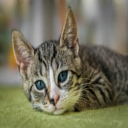

In [30]:


class Rose(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = PositionalEmbedding(12)
        # this is MLP (Multi layer Perceptron)
        self.net = torch.nn.Sequential(
            torch.nn.Linear(24, 256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 3),
        )

    def forward(self, x):
        return self.net(self.enc(x))


rose_tensor = torch.as_tensor(np.array(im_small), dtype=torch.float32) / 255.0 - 0.5
position = torch.stack(torch.meshgrid(torch.linspace(-1, 1, 128), torch.linspace(-1, 1, 128)), dim=-1)


net = Rose()

rose_tensor = rose_tensor.cuda()
position = position.cuda()
net = net.cuda()

optim = torch.optim.Adam(net.parameters(), lr=1e-3)
for it in range(5000):
    optim.zero_grad()
    loss = abs(net(position) - rose_tensor).mean()
    if it % 100 == 0:
        print(float(loss))
    loss.backward()
    optim.step()

Image.fromarray(((net(position) + 0.5).clamp(0, 1) * 255).cpu().to(torch.uint8).numpy())

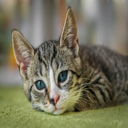

In [31]:
im_small

In [32]:
position_hires = torch.stack(torch.meshgrid(torch.linspace(-1, 1, 1024), torch.linspace(-1, 1, 1024)), dim=-1).cuda()

Image.fromarray(((net(position_hires) + 0.5).clamp(0, 1) * 255).cpu().to(torch.uint8).numpy())

OutOfMemoryError: CUDA out of memory. Tried to allocate 1024.00 MiB. GPU 0 has a total capacity of 1.95 GiB of which 786.06 MiB is free. Including non-PyTorch memory, this process has 1.17 GiB memory in use. Of the allocated memory 1.12 GiB is allocated by PyTorch, and 12.70 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# The below Transformer Layer follows exactly what was taught in class
# We are allowed to also use inbuilt Transformer class
class TransformerLayer(torch.nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()

        self.self_att = torch.nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.mlp = torch.nn.Sequential(
            torch.nn.Linear(embed_dim, 4 * embed_dim), torch.nn.ReLU(), torch.nn.Linear(4 * embed_dim, embed_dim)
        )
        self.in_norm = torch.nn.LayerNorm(embed_dim)
        self.mlp_norm = torch.nn.LayerNorm(embed_dim)

    def forward(self, x):
        x_norm = self.in_norm(x)
        x = x + self.self_att(x_norm, x_norm, x_norm)[0]
        x = x + self.mlp(self.mlp_norm(x))
        return x


class Transformer(torch.nn.Module):
    def __init__(self, embed_dim, num_heads, num_layers):
        super().__init__()
        self.network = torch.nn.Sequential(*[TransformerLayer(embed_dim, num_heads) for _ in range(num_layers)])

    def forward(self, x):
        return self.network(x)


net = Transformer(128, 8, 4)
# Batch x # tokens x embedding of each token
net(torch.rand(16, 10, 128)).shape

In [ ]:
# torch.nn.Embedding()